Scanning 'sim_results'...
Saved: paired_geometric_drift.png


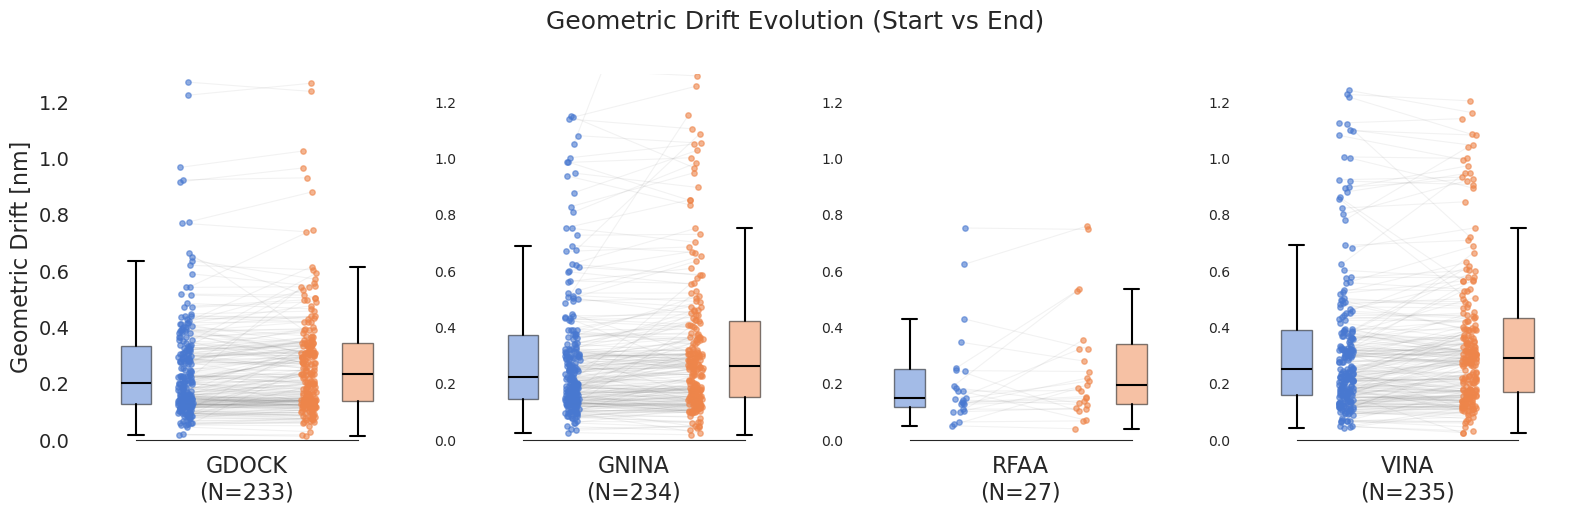


                                     SIGN TEST RESULTS (Paired Binomial)                                      
Program                   | N      | p(2-sided)  | p(greater)  | Signif?  | % Drift | Result
--------------------------------------------------------------------------------------------------------------
GDOCK                     | 233    | 2.51e-03    | 1.25e-03    | YES      | 0.601   | DRIFT
GNINA                     | 234    | 1.06e-02    | 5.32e-03    | YES      | 0.585   | DRIFT
RFAA                      | 27     | 4.42e-01    | 2.21e-01    | NO       | 0.593   | DRIFT
VINA                      | 235    | 6.75e-02    | 3.38e-02    | NO       | 0.562   | DRIFT


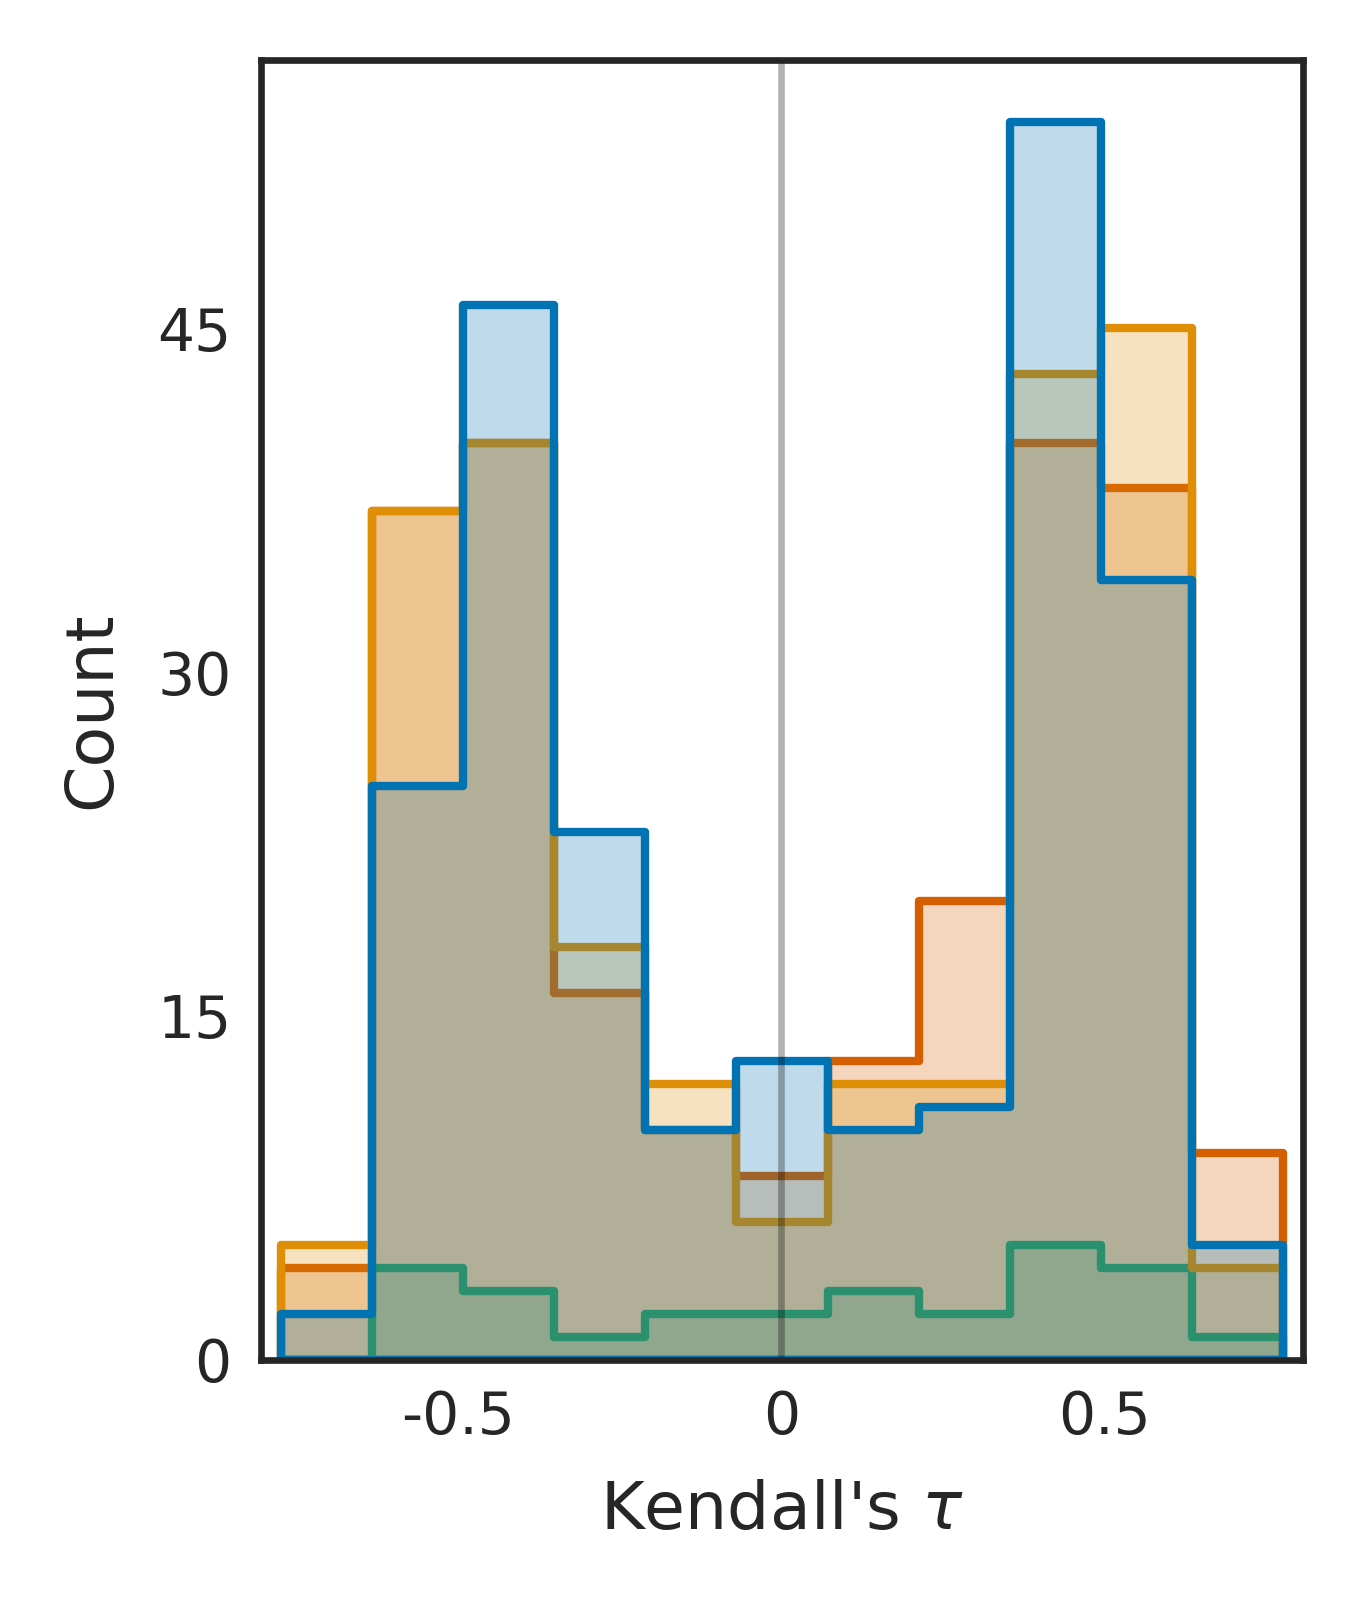

In [4]:
import os
import glob
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import binomtest
from matplotlib.ticker import MaxNLocator

# ==========================================
# CONFIGURATION
# ==========================================
DIRECTORY = "sim_results"
CHUNK_SIZE = 117
TARGET_METRIC = "Diff_to_Ref"
Y_LIMIT = 1.3

# Tau histogram figure settings
TAU_FIG_SIZE = (2.1, 2.5)
TAU_DPI = 600

# ==========================================
# HELPER FUNCTIONS
# ==========================================

def get_simulation_means(data_array, chunk_size):
    n_sims = len(data_array) // chunk_size
    if n_sims < 1:
        return np.array([])
    cutoff = n_sims * chunk_size
    return data_array[:cutoff].reshape(n_sims, chunk_size).mean(axis=1)


def run_paired_stats(v1, v2):
    """
    Paired Sign Test (Binomial).
    Returns two-sided p-value, directional p-value, and proportion increased.
    """
    if len(v1) == 0 or len(v2) == 0:
        return 1.0, 1.0, 0.5

    diffs = v1 - v2
    n_decreased = np.sum(diffs > 0)  # Value went down (tightened)
    n_increased = np.sum(diffs < 0)  # Value went up (drifted)
    n_valid = n_decreased + n_increased

    if n_valid == 0:
        return 1.0, 1.0, 0.5

    p_two = binomtest(n_increased, n_valid, p=0.5, alternative='two-sided').pvalue
    p_greater = binomtest(n_increased, n_valid, p=0.5, alternative='greater').pvalue
    prop_increased = n_increased / n_valid

    return p_two, p_greater, prop_increased


def interpret_effect(prop_increased):
    if prop_increased > 0.55:
        return "DRIFT"
    if prop_increased < 0.45:
        return "TIGHTEN"
    return "Stable"

# ==========================================
# PLOTTING
# ==========================================

def plot_paired_box_slope(data_store):
    """Paired box-slope plot showing geometric drift from start to end of simulation."""
    if TARGET_METRIC not in data_store:
        print(f"Metric '{TARGET_METRIC}' not found in data.")
        return

    programs = data_store[TARGET_METRIC]
    prog_names = sorted(programs.keys())
    n_progs = len(prog_names)

    if n_progs == 0:
        return

    try:
        plt.style.use(['science', 'no-latex', 'nature'])
    except:
        sns.set_style("white")

    muted_colors = sns.color_palette("muted")
    c_p1 = muted_colors[0]  # Part 1 (Start)
    c_p2 = muted_colors[1]  # Part 2 (End)

    fig, axes = plt.subplots(1, n_progs, figsize=(4 * n_progs, 5))
    if n_progs == 1:
        axes = [axes]

    for i, prog in enumerate(prog_names):
        ax = axes[i]
        p1 = np.array(programs[prog]['means_p1'])
        p2 = np.array(programs[prog]['means_p2'])

        if len(p1) == 0:
            continue

        pos_box1, pos_pts1 = -0.4, 0.0
        pos_pts2, pos_box2 = 1.0, 1.4
        jit_width = 0.06

        jitter = np.random.uniform(-jit_width, jit_width, size=len(p1))
        x_start = pos_pts1 + jitter
        x_end = pos_pts2 + jitter

        # Connecting lines
        for j in range(len(p1)):
            ax.plot([x_start[j], x_end[j]], [p1[j], p2[j]],
                    color='gray', alpha=0.1, linewidth=0.8, zorder=1)

        # Points
        ax.scatter(x_start, p1, s=15, color=c_p1, alpha=0.6, zorder=2)
        ax.scatter(x_end, p2, s=15, color=c_p2, alpha=0.6, zorder=2)

        # Boxplots
        bp1 = ax.boxplot([p1], positions=[pos_box1], widths=0.25,
                         patch_artist=True, showfliers=False, zorder=3)
        bp2 = ax.boxplot([p2], positions=[pos_box2], widths=0.25,
                         patch_artist=True, showfliers=False, zorder=3)

        for patch in bp1['boxes']:
            patch.set_facecolor(c_p1)
            patch.set_alpha(0.5)
        for patch in bp2['boxes']:
            patch.set_facecolor(c_p2)
            patch.set_alpha(0.5)
        for bp in [bp1, bp2]:
            for element in ['whiskers', 'caps', 'medians']:
                plt.setp(bp[element], color='black', linewidth=1.5)

        ax.set_xlabel(f"{prog}\n(N={len(p1)})", fontsize=16)
        ax.set_xticks([pos_box1, pos_pts1, pos_pts2, pos_box2])
        ax.set_xticklabels(["", "", "", ""])

        if i == 0:
            ax.set_ylabel("Geometric Drift [nm]", fontsize=16)
            ax.tick_params(axis='y', labelsize=14, length=0)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', length=0)

        ax.set_ylim(bottom=0, top=Y_LIMIT)
        ax.yaxis.grid(False)
        sns.despine(ax=ax, trim=True, left=True)

    plt.suptitle("Geometric Drift Evolution (Start vs End)", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig("paired_geometric_drift.png", dpi=300, bbox_inches='tight')
    print("Saved: paired_geometric_drift.png")
    plt.show()

# ==========================================
# DATA LOADING
# ==========================================

data_store = {}
print(f"Scanning '{DIRECTORY}'...")
part1_files = glob.glob(os.path.join(DIRECTORY, "*part_1.csv"))

for p1_path in part1_files:
    filename = os.path.basename(p1_path)
    if TARGET_METRIC not in filename:
        continue

    match = re.match(r"^(.*)_(Diff_to_Ref|Diff_to_Docked)_part_1\.csv$", filename)
    if not match:
        continue

    prog, metric = match.groups()
    prog = prog.upper()

    data_store.setdefault(metric, {})
    data_store[metric].setdefault(prog, {'means_p1': [], 'means_p2': [], 'trajectories': []})

    p2_path = p1_path.replace('part_1.csv', 'part_2.csv')
    if not os.path.exists(p2_path):
        print(f"  [Warning] Missing Part 2 for {filename}, skipping.")
        continue

    try:
        raw1 = pd.to_numeric(pd.read_csv(p1_path).iloc[:, 0], errors='coerce').dropna().values
        raw2 = pd.to_numeric(pd.read_csv(p2_path).iloc[:, 0], errors='coerce').dropna().values

        min_len = min(len(raw1), len(raw2))
        data_store[metric][prog]['means_p1'].extend(get_simulation_means(raw1[:min_len], CHUNK_SIZE))
        data_store[metric][prog]['means_p2'].extend(get_simulation_means(raw2[:min_len], CHUNK_SIZE))

        # Raw trajectories for Kendall Tau
        stitched = np.concatenate([raw1[:min_len], raw2[:min_len]])
        full_sim_len = CHUNK_SIZE * 2
        n_sims = len(stitched) // full_sim_len
        if n_sims > 0:
            truncated = stitched[:n_sims * full_sim_len]
            data_store[metric][prog]['trajectories'].extend(np.split(truncated, n_sims))

    except Exception as e:
        print(f"  [Error] {filename}: {e}")

# ==========================================
# EXECUTION
# ==========================================

# --- Paired Box-Slope Plot ---
plot_paired_box_slope(data_store)

# --- Sign Test Results ---
if TARGET_METRIC in data_store:
    print(f"\n{'='*110}")
    print("SIGN TEST RESULTS (Paired Binomial)".center(110))
    print(f"{'='*110}")
    print(f"{'Program':<25} | {'N':<6} | {'p(2-sided)':<11} | {'p(greater)':<11} | {'Signif?':<8} | {'% Drift':<7} | {'Result'}")
    print(f"{'-'*110}")

    for prog in sorted(data_store[TARGET_METRIC].keys()):
        p1 = np.array(data_store[TARGET_METRIC][prog]['means_p1'])
        p2 = np.array(data_store[TARGET_METRIC][prog]['means_p2'])

        if len(p1) == 0:
            continue

        p_two, p_greater, prop_drift = run_paired_stats(p1, p2)
        sig = "YES" if p_two < 0.05 else "NO"
        res = interpret_effect(prop_drift)

        print(f"{prog:<25} | {len(p1):<6} | {p_two:<11.2e} | {p_greater:<11.2e} | {sig:<8} | {prop_drift:.3f}   | {res}")

# ==========================================
# KENDALL TAU HISTOGRAM
# ==========================================

def plot_tau_histogram(df_mk, program_colors):
    """Mini Kendall Tau histogram panel, sized for publication."""
    if df_mk.empty:
        print("No Tau data to plot.")
        return

    fig, ax = plt.subplots(figsize=TAU_FIG_SIZE, dpi=TAU_DPI)

    sns.histplot(
        data=df_mk, x="Tau", hue="Program",
        palette=program_colors,
        element="step",
        kde=False,
        legend=False,
        ax=ax
    )

    # Dynamic x range with small margin
    t_min, t_max = df_mk['Tau'].min(), df_mk['Tau'].max()
    x_margin = (t_max - t_min) * 0.02 if t_max != t_min else 0.1
    ax.set_xlim(t_min - x_margin, t_max + x_margin)

    # Only show ticks that fall within actual data range
    visible_ticks = [t for t in [-0.5, 0, 0.5] if t_min <= t <= t_max]
    ax.set_xticks(visible_ticks)
    ax.set_xticklabels(visible_ticks, fontsize=7)

    ax.tick_params(axis='both', which='both', labelsize=7, direction='in',
                   left=True, right=True, bottom=True, top=True, length=0)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    ax.axvline(0, color='black', linewidth=0.8, alpha=0.3)
    ax.set_xlabel(r"Kendall's $\tau$", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)

    plt.tight_layout(pad=0.1)
    filename = "plot_tau_geometric_clean_x.png"
    plt.savefig(filename, dpi=TAU_DPI, bbox_inches='tight')
    plt.show()
    plt.close(fig)


if TARGET_METRIC in data_store:
    unique_programs = sorted(data_store[TARGET_METRIC].keys())
    program_colors = dict(zip(unique_programs, sns.color_palette("colorblind", n_colors=len(unique_programs))))

    mk_data = []
    for prog in unique_programs:
        for y in data_store[TARGET_METRIC][prog].get('trajectories', []):
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    tau, _ = stats.kendalltau(np.arange(len(y)), y)
                val = tau if not (np.isnan(tau) or np.isinf(tau)) else 0.0
            except:
                val = 0.0
            mk_data.append({'Program': prog, 'Tau': val})

    df_mk = pd.DataFrame(mk_data)
    plot_tau_histogram(df_mk, program_colors)